# **Driver drowsiness system**

Dataset Links:
- https://www.kaggle.com/datasets/samymesbah/nthu-dataset-ddd-multi-class

#### **Dataset Downloads**

**Google Colab**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d samymesbah/nthu-dataset-ddd-multi-class
!unzip -q nthu-dataset-ddd-multi-class.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/samymesbah/nthu-dataset-ddd-multi-class
License(s): unknown
100% 1.99G/1.99G [00:19<00:00, 110MB/s]



**Libraries**

In [3]:
import os
import shutil
import warnings
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

warnings.filterwarnings('ignore')

#### **Rearranging Dataset Directory**

In [4]:
root_dir = "Multi class"
drowsy_dir = "Multi class/train/drowsy"
nondrowsy_dir = "Multi class/train/notdrowsy"

In [5]:
# Moving all classes in drowsy to datasets

for d in os.listdir(drowsy_dir):
    src_path = os.path.join(drowsy_dir, d)
    dst_path = root_dir
    shutil.move(src_path, dst_path)


In [6]:
shutil.move(nondrowsy_dir, root_dir)

'Multi class/notdrowsy'

In [7]:
shutil.rmtree(drowsy_dir)
shutil.rmtree("Multi class/train")

#### **Final Dataset**

In [8]:
parent_dir = "Multi class"

In [9]:
# Count of images in each class

count_of_images = {}
for l in os.listdir(parent_dir):
    count_of_images[l] = len(os.listdir(os.path.join(dst_path, l)))

In [10]:
count_of_images

{'yawning': 8862,
 'notdrowsy': 30491,
 'slowBlinkWithNodding': 9412,
 'sleepyCombination': 17756}

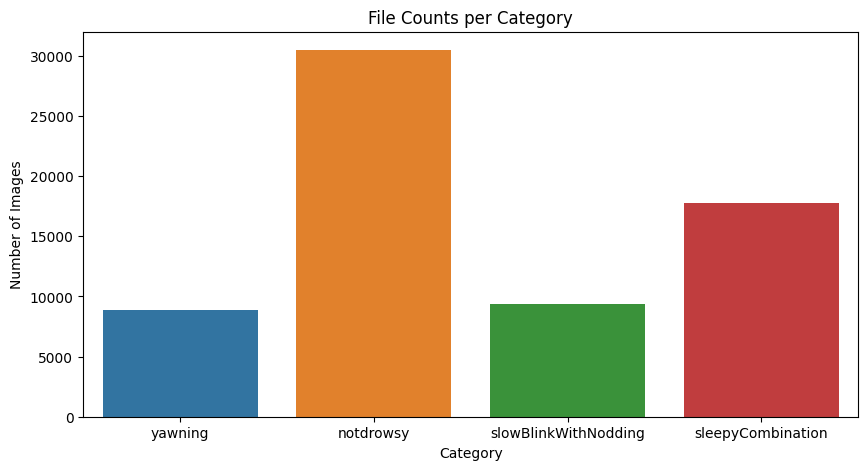

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(x=count_of_images.keys(), y=count_of_images.values(), hue=count_of_images.keys())
plt.title('File Counts per Category')
plt.ylabel('Number of Images')
plt.xlabel('Category')
plt.show()

## **Sample Data Visualization**

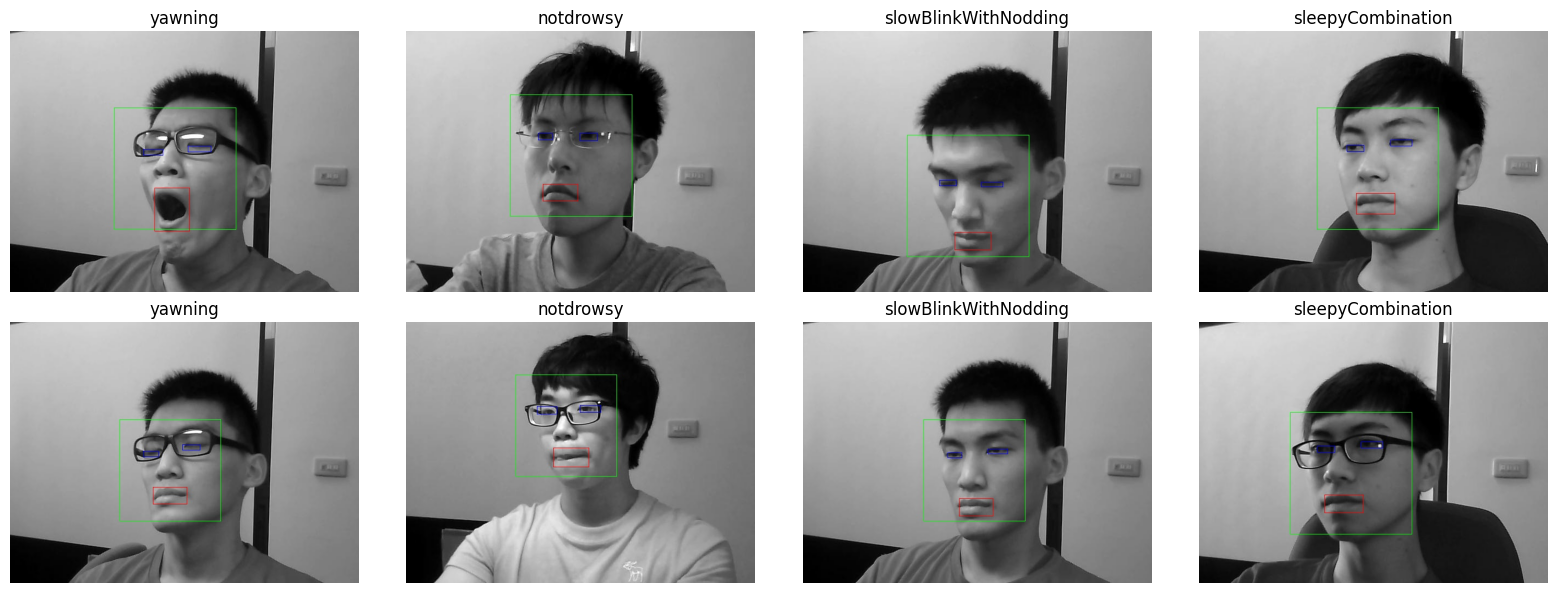

In [12]:
import matplotlib.image as mpimg
dst_path = parent_dir
categories = os.listdir(dst_path)
dir_path = 'Multi class'

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, category in enumerate(categories):
    folder = os.path.join(dir_path, category)
    images = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    sample_imgs = random.sample(images, 2) if len(images) >= 2 else images
    for j, img_name in enumerate(sample_imgs):

        ax = axes[j, i]
        img_path = os.path.join(folder, img_name)
        img = mpimg.imread(img_path)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"{category}")
        ax.axis('off')

    for j in range(len(sample_imgs), 2):
        axes[j, i].axis('off')

plt.tight_layout()
plt.show()


## **Data Splitting - Train, Test and Validation**

In [13]:
# Paths
source_dir = "Multi class"
target_dir = "Model Data"

classes = categories

# Create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".jpg")]

    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Copy files
    for img in train_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "test", cls, img)
        )

print("Dataset successfully split into Train (70%), Val (15%), Test (15%)")

Dataset successfully split into Train (70%), Val (15%), Test (15%)


In [14]:
train_parent_dir = "Model Data/train"
print("Count of Images for each class in train directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(train_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in train directory
yawning has 6203 images
notdrowsy has 21343 images
slowBlinkWithNodding has 6588 images
sleepyCombination has 12429 images


In [15]:
val_parent_dir = "Model Data/val"
print("Count of Images for each class in val directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(val_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in val directory
yawning has 1329 images
notdrowsy has 4573 images
slowBlinkWithNodding has 1411 images
sleepyCombination has 2663 images


In [16]:
test_parent_dir = "Model Data/test"
print("Count of Images for each class in test directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(test_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in test directory
yawning has 1330 images
notdrowsy has 4575 images
slowBlinkWithNodding has 1413 images
sleepyCombination has 2664 images


## **Data Augmentation**

In [17]:
train_dir = "Model Data/train"
val_dir = "Model Data/val"
test_dir = "Model Data/test"

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:
img_dims = (128, 128)
batch_size = 64

In [20]:
train_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = train_data.flow_from_directory(
    directory=train_dir,
    target_size= img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

Found 46563 images belonging to 4 classes.


In [21]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_test_datagen.flow_from_directory(
    directory=val_dir,
    target_size=img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

Found 9976 images belonging to 4 classes.


In [22]:
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 9982 images belonging to 4 classes.


In [23]:
train_generator.class_indices

{'notdrowsy': 0,
 'sleepyCombination': 1,
 'slowBlinkWithNodding': 2,
 'yawning': 3}

## **Class Imbalace Check**

In [24]:
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

# Imbalance Ratio
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Class Labels: {'notdrowsy': 0, 'sleepyCombination': 1, 'slowBlinkWithNodding': 2, 'yawning': 3}

Imbalance Ratio: 3.44


## **Class Weights**

In [25]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(0.5454130159771353), 1: np.float64(0.936579773111272), 2: np.float64(1.7669626593806922), 3: np.float64(1.8766322747057875)}


# **Model Building**

In [26]:
class_len = train_generator.num_classes
epochs = 10

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=3)
]

In [28]:
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import random

#### **CNN**

In [29]:
def build_custom_cnn(input_shape=(img_dims[0],img_dims[1],3), num_classes= len(train_generator.class_indices)):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(class_len, activation='softmax')
    ])
    return model

In [30]:
custom_model = build_custom_cnn()
custom_model.compile(optimizer=Adam(0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

In [31]:
history_custom = custom_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 315s 421ms/step - accuracy: 0.3231 - loss: 1.2992 - val_accuracy: 0.4989 - val_loss: 1.1447 - learning_rate: 0.0010
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 296s 407ms/step - accuracy: 0.4775 - loss: 1.0548 - val_accuracy: 0.5832 - val_loss: 0.8812 - learning_rate: 0.0010
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 290s 399ms/step - accuracy: 0.5844 - loss: 0.8736 - val_accuracy: 0.6908 - val_loss: 0.7442 - learning_rate: 0.0010
Epoch 4/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 292s 402ms/step - accuracy: 0.6433 - loss: 0.7556 - val_accuracy: 0.7253 - val_loss: 0.6422 - learning_rate: 0.0010
Epoch 5/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 297s 407ms/step - accuracy: 0.6850 - loss: 0.6734 - val_accuracy: 0.7718 - val_loss: 0.5841 - learning_rate: 0.0010
Epoch 6/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 312s 428ms/step - accuracy: 0.7128 - loss: 0.6118 - val_accuracy: 0.7754 - val_loss: 0.5363 - learning_rate: 0.0010
Epoch 7/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 288s 396ms/step - accura

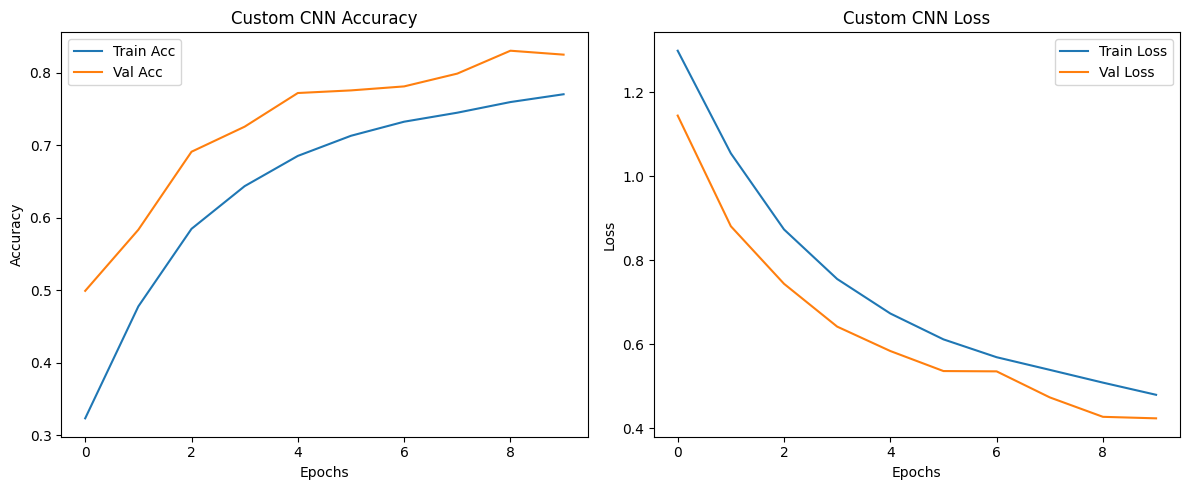

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_custom.history['accuracy'], label='Train Acc')
axes[0].plot(history_custom.history['val_accuracy'], label='Val Acc')
axes[0].set_title("Custom CNN Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_custom.history['loss'], label='Train Loss')
axes[1].plot(history_custom.history['val_loss'], label='Val Loss')
axes[1].set_title("Custom CNN Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

#### **MobileNetV2**

In [33]:
base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_dims[0],img_dims[1],3))
base_mobilenet.trainable = False

x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(class_len, activation='softmax')(x)

mobilenet_model = Model(inputs=base_mobilenet.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [34]:
mobilenet_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [83]:
history_mob = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    epochs=epochs
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 320s 440ms/step - accuracy: 0.6162 - loss: 0.8716 - val_accuracy: 0.6266 - val_loss: 0.9772 - learning_rate: 0.0010
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 297s 407ms/step - accuracy: 0.7177 - loss: 0.6394 - val_accuracy: 0.7260 - val_loss: 0.6975 - learning_rate: 0.0010
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 296s 407ms/step - accuracy: 0.7509 - loss: 0.5584 - val_accuracy: 0.6871 - val_loss: 0.8328 - learning_rate: 0.0010


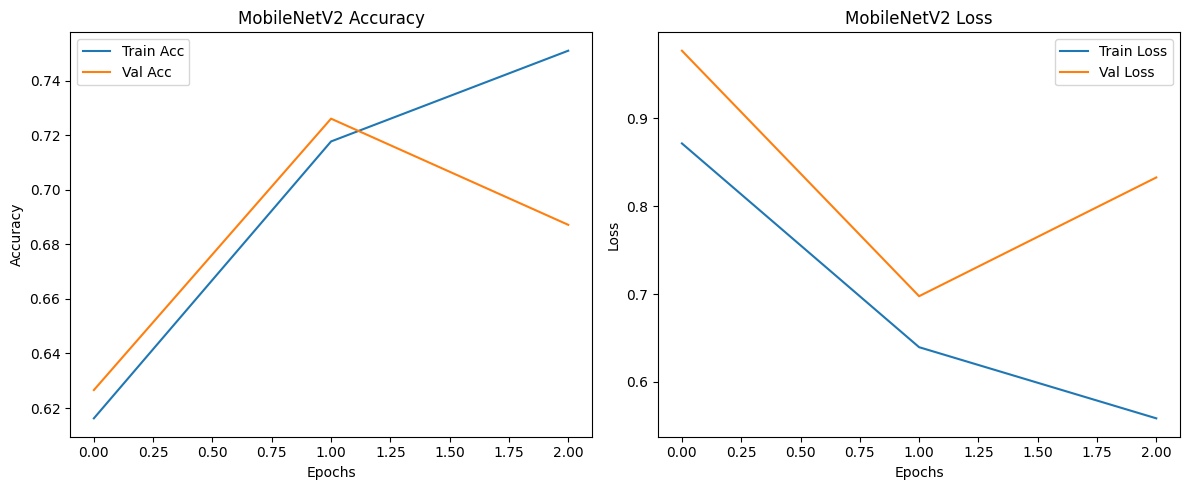

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_mob.history['accuracy'], label='Train Acc')
axes[0].plot(history_mob.history['val_accuracy'], label='Val Acc')
axes[0].set_title("MobileNetV2 Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_mob.history['loss'], label='Train Loss')
axes[1].plot(history_mob.history['val_loss'], label='Val Loss')
axes[1].set_title("MobileNetV2 Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

In [85]:
for layer in base_mobilenet.layers[-30:]:
    layer.trainable = True

mobilenet_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [86]:
history_mob_ft = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    epochs=epochs
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 331s 432ms/step - accuracy: 0.6371 - loss: 0.9003 - val_accuracy: 0.5661 - val_loss: 1.2352 - learning_rate: 1.0000e-05
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 309s 425ms/step - accuracy: 0.7294 - loss: 0.6143 - val_accuracy: 0.6555 - val_loss: 0.9299 - learning_rate: 1.0000e-05
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 310s 426ms/step - accuracy: 0.7698 - loss: 0.5140 - val_accuracy: 0.7078 - val_loss: 0.7855 - learning_rate: 1.0000e-05


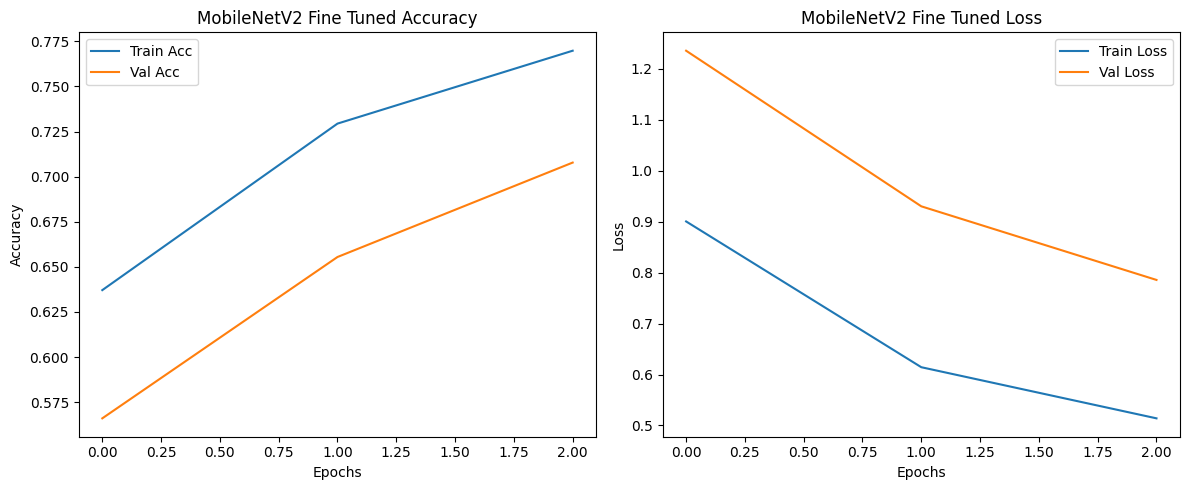

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_mob_ft.history['accuracy'], label='Train Acc')
axes[0].plot(history_mob_ft.history['val_accuracy'], label='Val Acc')
axes[0].set_title("MobileNetV2 Fine Tuned Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_mob_ft.history['loss'], label='Train Loss')
axes[1].plot(history_mob_ft.history['val_loss'], label='Val Loss')
axes[1].set_title("MobileNetV2 Fine Tuned Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

#### **VGG201**

In [88]:
from tensorflow.keras.applications import VGG16

In [89]:
vgg_base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_dims[0], img_dims[1], 3))

# Freeze the convolutional base
vgg_base_model.trainable = False

# Build your model
vgg_model = Sequential([
    vgg_base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(class_len, activation='softmax')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [90]:
vgg_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [91]:
history_vgg = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 360s 475ms/step - accuracy: 0.3343 - loss: 1.3571 - val_accuracy: 0.4629 - val_loss: 1.2021 - learning_rate: 1.0000e-05
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 326s 447ms/step - accuracy: 0.4570 - loss: 1.1740 - val_accuracy: 0.5782 - val_loss: 1.0707 - learning_rate: 1.0000e-05
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 327s 449ms/step - accuracy: 0.5202 - loss: 1.0715 - val_accuracy: 0.6858 - val_loss: 0.9319 - learning_rate: 1.0000e-05


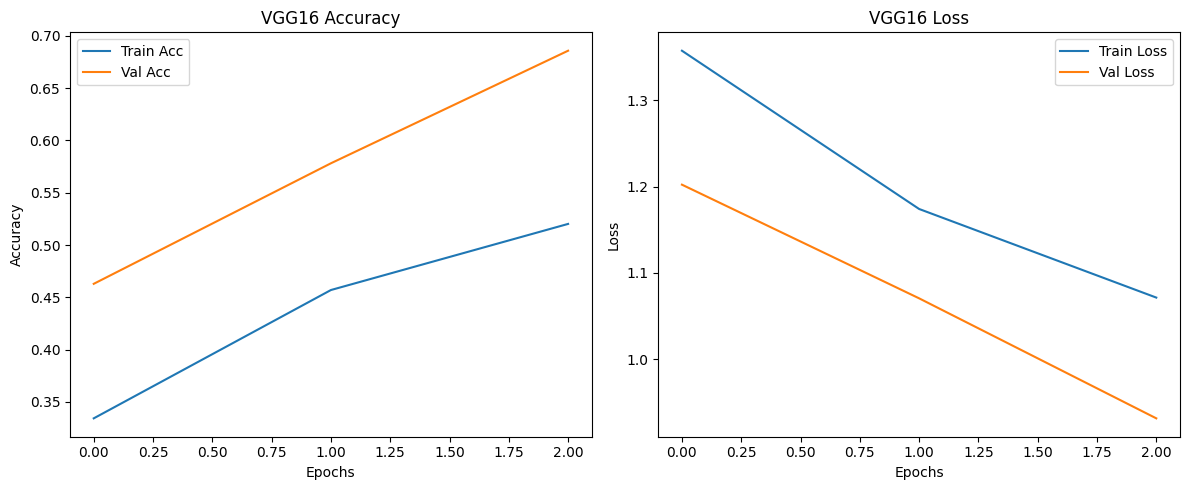

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_vgg.history['accuracy'], label='Train Acc')
axes[0].plot(history_vgg.history['val_accuracy'], label='Val Acc')
axes[0].set_title("VGG16 Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_vgg.history['loss'], label='Train Loss')
axes[1].plot(history_vgg.history['val_loss'], label='Val Loss')
axes[1].set_title("VGG16 Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

#### **ResNet50**

In [93]:
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(img_dims[0],img_dims[1],3))
base_resnet.trainable = False

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(class_len, activation='softmax')(x)

resnet_model = Model(inputs=base_resnet.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [94]:
resnet_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [95]:
history_res = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 341s 451ms/step - accuracy: 0.2640 - loss: 1.3867 - val_accuracy: 0.1416 - val_loss: 1.4171 - learning_rate: 0.0010
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 312s 428ms/step - accuracy: 0.2730 - loss: 1.3694 - val_accuracy: 0.2046 - val_loss: 1.3955 - learning_rate: 0.0010
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 347s 477ms/step - accuracy: 0.2855 - loss: 1.3543 - val_accuracy: 0.3138 - val_loss: 1.3431 - learning_rate: 0.0010


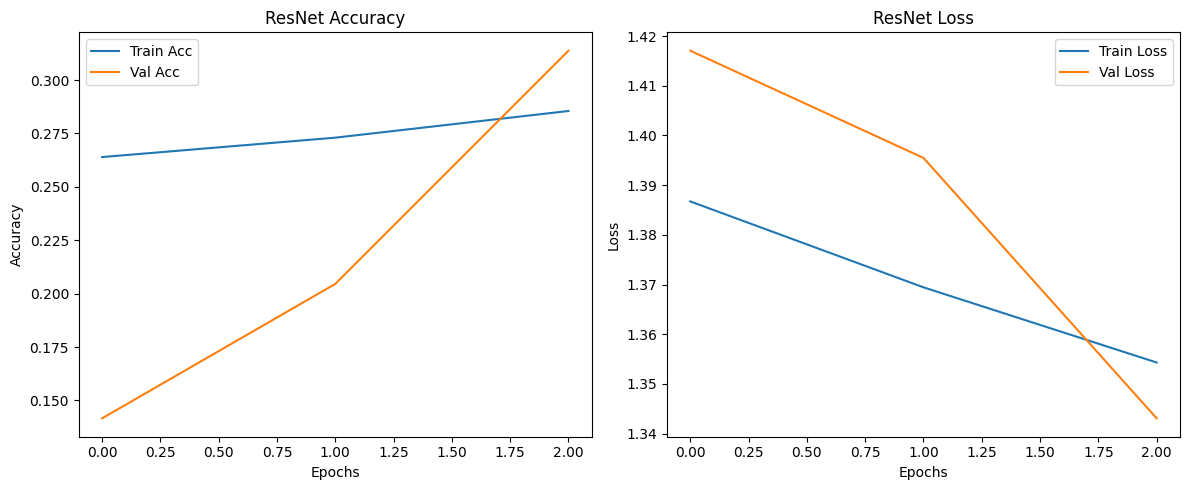

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_res.history['accuracy'], label='Train Acc')
axes[0].plot(history_res.history['val_accuracy'], label='Val Acc')
axes[0].set_title("ResNet Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_res.history['loss'], label='Train Loss')
axes[1].plot(history_res.history['val_loss'], label='Val Loss')
axes[1].set_title("ResNet Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

#### **DenseNet201**

In [97]:
from tensorflow.keras.applications import DenseNet201

In [98]:
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(img_dims[0], img_dims[1], 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(class_len, activation='softmax')(x)

densenet_model = Model(inputs=base_model.input, outputs=x)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [99]:
densenet_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [116]:
history_dense = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 448s 566ms/step - accuracy: 0.5170 - loss: 1.0493 - val_accuracy: 0.6770 - val_loss: 0.7827 - learning_rate: 0.0010
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 317s 435ms/step - accuracy: 0.6259 - loss: 0.8179 - val_accuracy: 0.6972 - val_loss: 0.7362 - learning_rate: 0.0010
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 324s 445ms/step - accuracy: 0.6671 - loss: 0.7309 - val_accuracy: 0.7232 - val_loss: 0.6917 - learning_rate: 0.0010


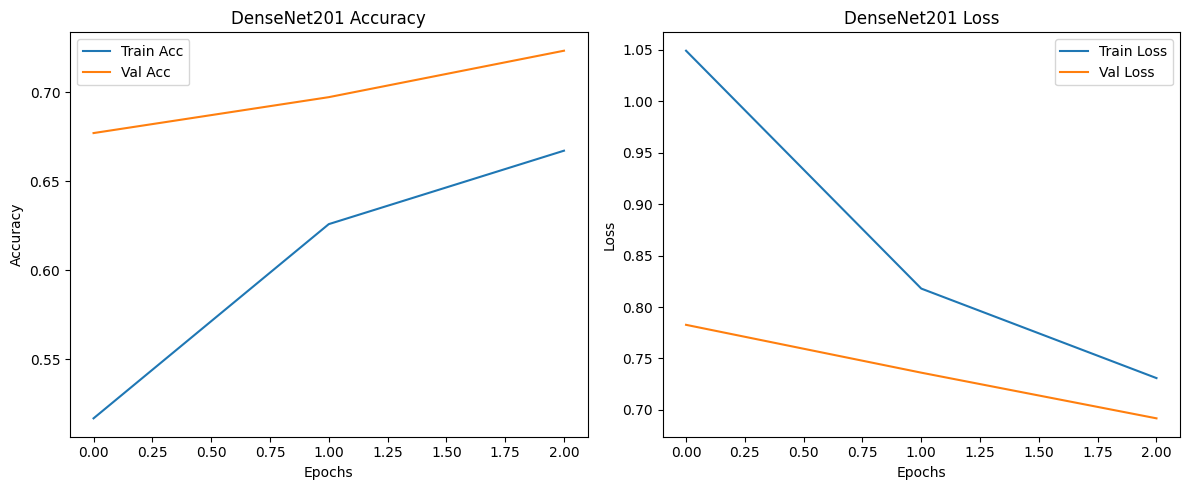

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_dense.history['accuracy'], label='Train Acc')
axes[0].plot(history_dense.history['val_accuracy'], label='Val Acc')
axes[0].set_title("DenseNet201 Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_dense.history['loss'], label='Train Loss')
axes[1].plot(history_dense.history['val_loss'], label='Val Loss')
axes[1].set_title("DenseNet201 Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

## **Metrics**

In [101]:
def evaluate_model(model, name):
    y_true = test_generator.classes
    y_pred = np.argmax(model.predict(test_generator), axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return [name, acc, prec, rec, f1], y_true, y_pred

In [102]:
model_results = []

cnn_metrics, y_true, y_pred_cnn = evaluate_model(custom_model, "Custom CNN")
model_results.append(cnn_metrics)

156/156 ━━━━━━━━━━━━━━━━━━━━ 27s 169ms/step


In [103]:
mob_metrics, _, y_pred_mob = evaluate_model(mobilenet_model, "MobileNetV2")
model_results.append(mob_metrics)

156/156 ━━━━━━━━━━━━━━━━━━━━ 38s 216ms/step


In [104]:
vgg_metrics, _, y_pred_vgg = evaluate_model(vgg_model, "VGG16")
model_results.append(vgg_metrics)

156/156 ━━━━━━━━━━━━━━━━━━━━ 36s 224ms/step


In [105]:
res_metrics, _, y_pred_res = evaluate_model(resnet_model, "ResNet50")
model_results.append(res_metrics)

156/156 ━━━━━━━━━━━━━━━━━━━━ 32s 178ms/step


In [118]:
dense_metrics, _, y_pred_dense = evaluate_model(densenet_model, "DenseNet201")
model_results.append(dense_metrics)

156/156 ━━━━━━━━━━━━━━━━━━━━ 53s 342ms/step


In [119]:
df_results = pd.DataFrame(model_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
df_results

,Model,Accuracy,Precision,Recall,F1
0,Custom CNN,0.812863,0.826349,0.812863,0.813905
1,MobileNetV2,0.571028,0.738050,0.571028,0.548856
2,VGG16,0.456221,0.600732,0.456221,0.458309
3,ResNet50,0.141555,0.020052,0.141555,0.035128
4,DenseNet201,0.667401,0.736147,0.667401,0.672274


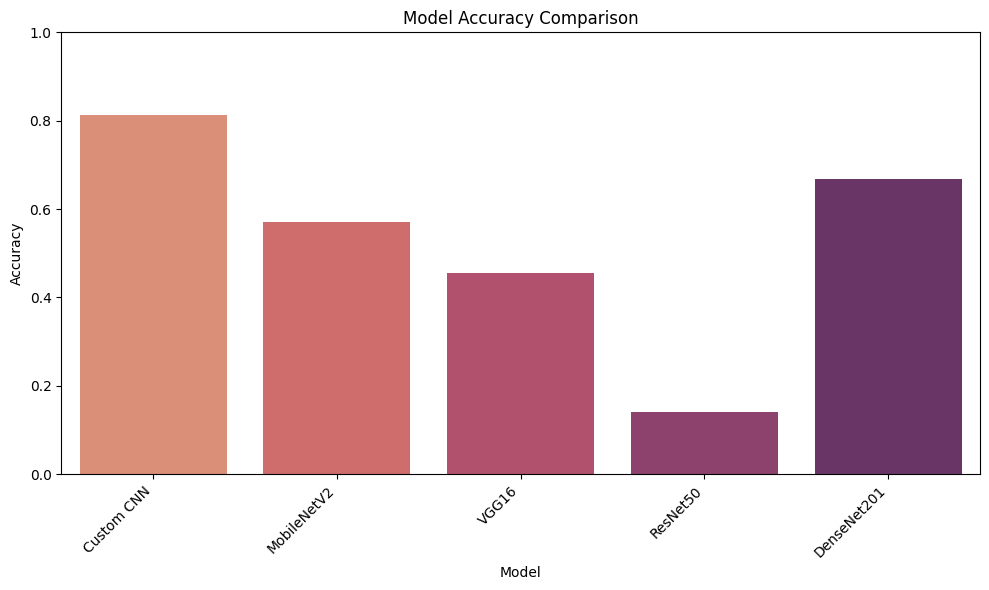

In [120]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=df_results, palette='flare')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

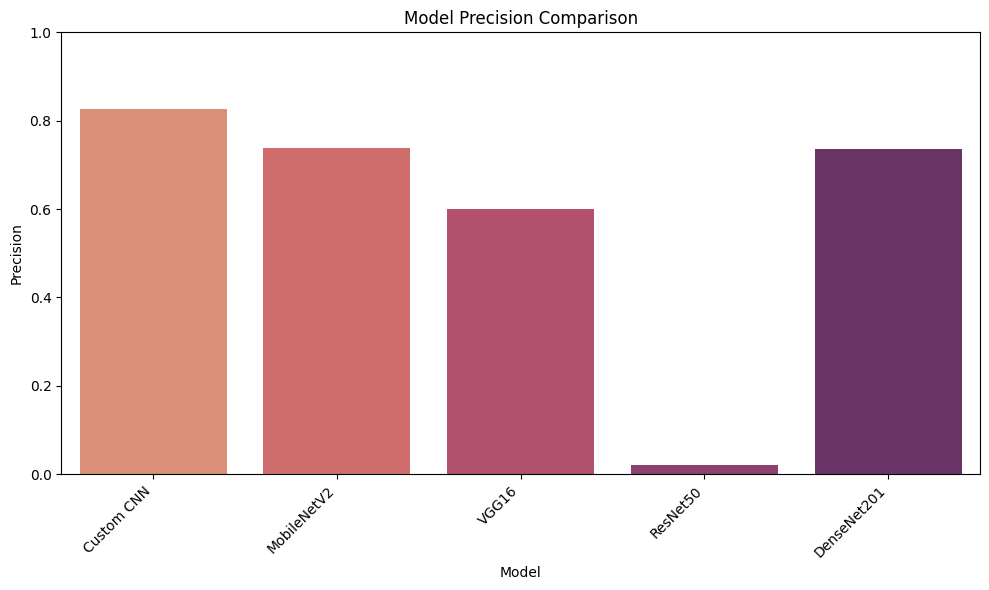

In [121]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Precision', data=df_results, palette='flare')
plt.title('Model Precision Comparison')
plt.xlabel('Model')
plt.ylabel('Precision')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

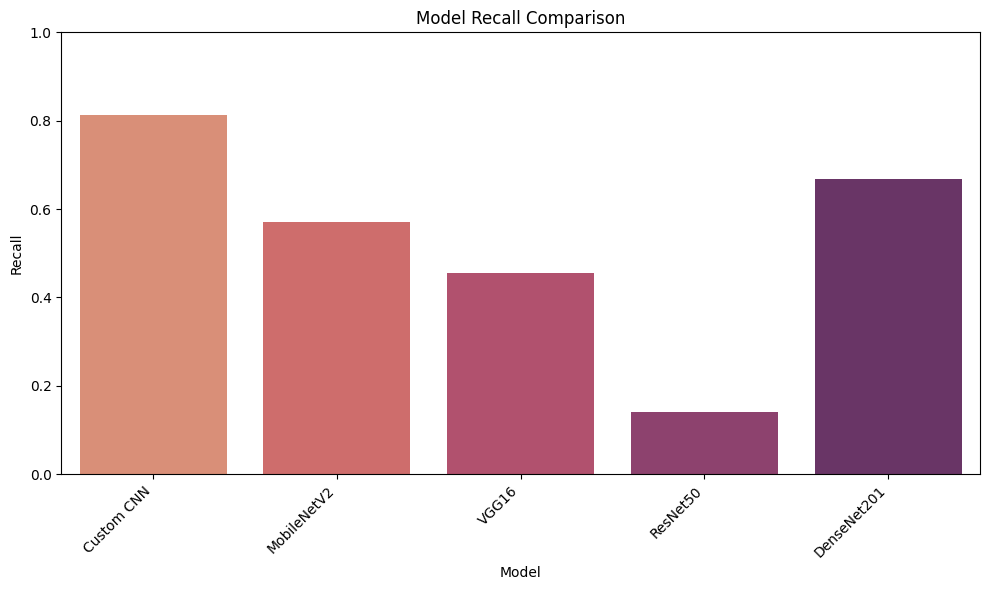

In [122]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Recall', data=df_results, palette='flare')
plt.title('Model Recall Comparison')
plt.xlabel('Model')
plt.ylabel('Recall')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

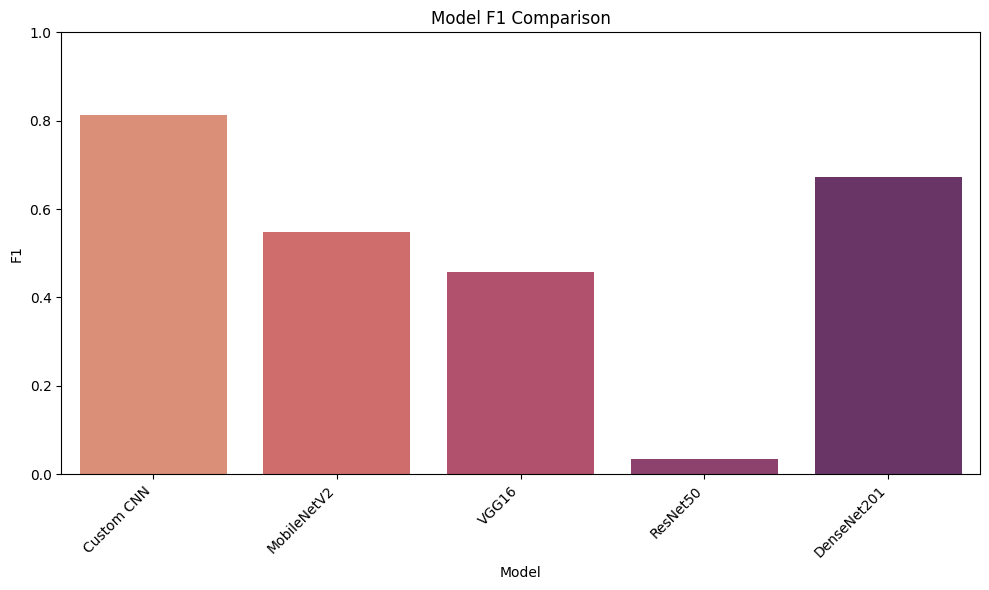

In [123]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1', data=df_results, palette='flare')
plt.title('Model F1 Comparison')
plt.xlabel('Model')
plt.ylabel('F1')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Confusion Matrix**

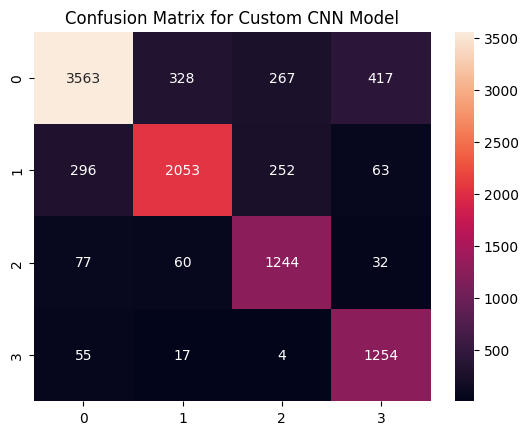

In [107]:
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

sns.heatmap(cm_cnn, annot=True, fmt='d')
plt.title("Confusion Matrix for Custom CNN Model")
plt.show()

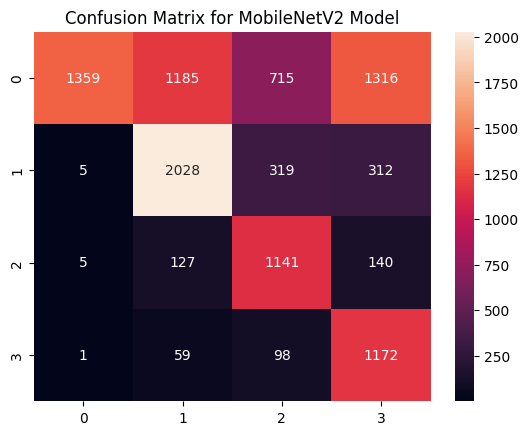

In [108]:
cm_mob = confusion_matrix(y_true, y_pred_mob)
sns.heatmap(cm_mob, annot=True, fmt='d')
plt.title("Confusion Matrix for MobileNetV2 Model")
plt.show()

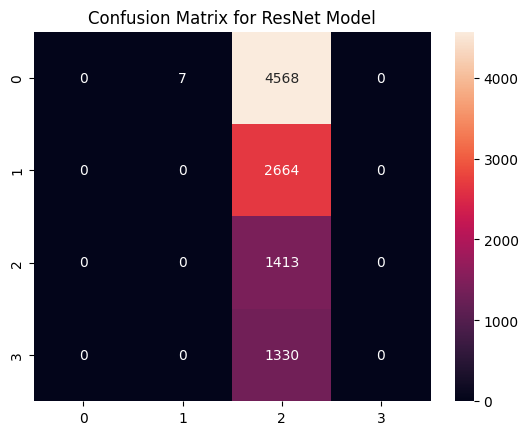

In [109]:
cm_res = confusion_matrix(y_true, y_pred_res)

sns.heatmap(cm_res, annot=True, fmt='d')
plt.title("Confusion Matrix for ResNet Model")
plt.show()

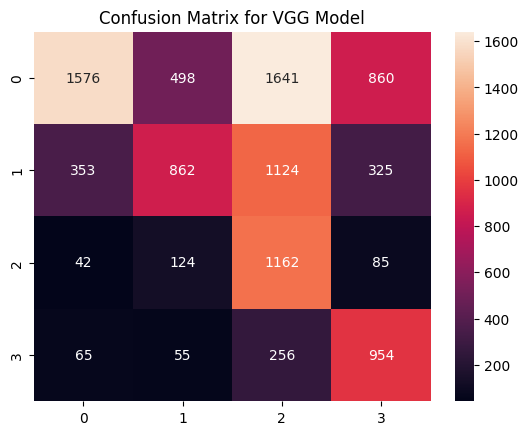

In [110]:
cm_vgg = confusion_matrix(y_true, y_pred_vgg)

sns.heatmap(cm_vgg, annot=True, fmt='d')
plt.title("Confusion Matrix for VGG Model")
plt.show()

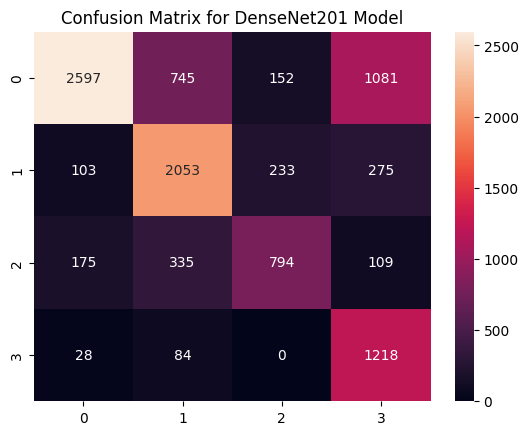

In [124]:
cm_dense = confusion_matrix(y_true, y_pred_dense)

sns.heatmap(cm_dense, annot=True, fmt='d')
plt.title("Confusion Matrix for DenseNet201 Model")
plt.show()

## **ROC Curve**

156/156 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step


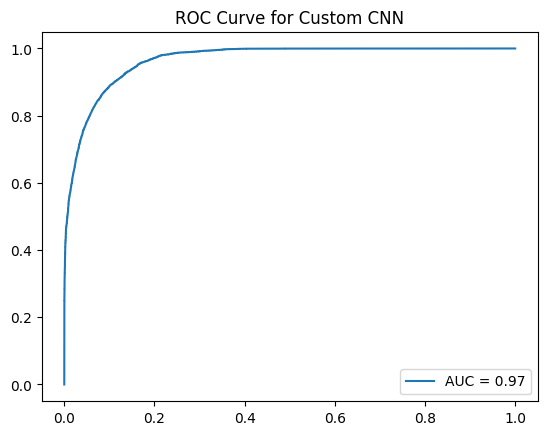

In [111]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = custom_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for Custom CNN")
plt.show()

156/156 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step


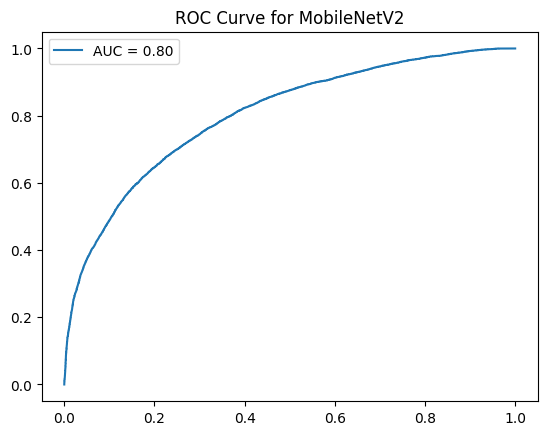

In [112]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = mobilenet_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for MobileNetV2")
plt.show()

156/156 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step


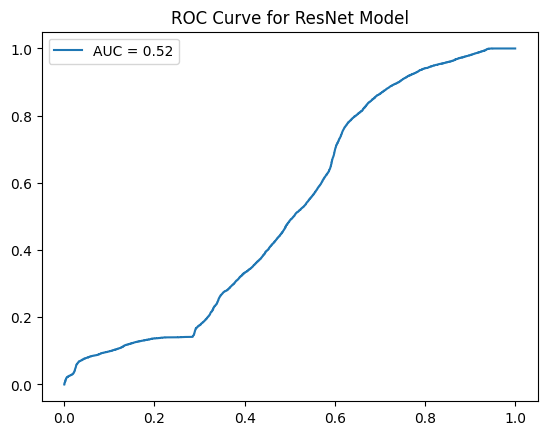

In [113]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = resnet_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for ResNet Model")
plt.show()

156/156 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step


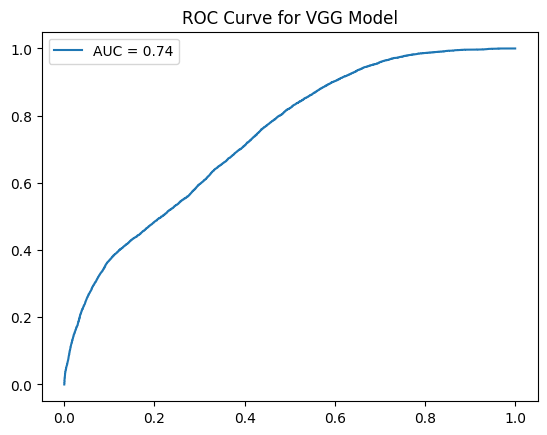

In [114]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = vgg_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for VGG Model")
plt.show()

156/156 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step


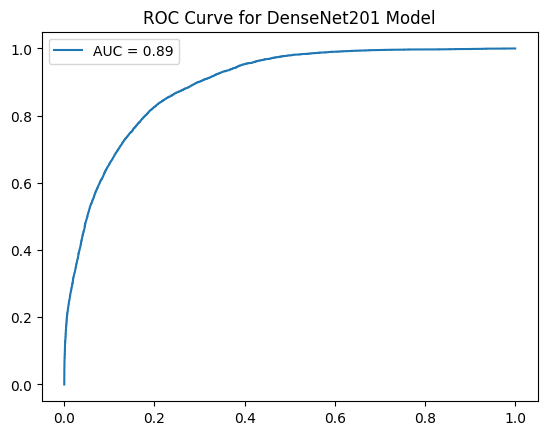

In [125]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = densenet_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for DenseNet201 Model")
plt.show()

## **Test Predictions**

In [126]:
best_model_name = df_results.sort_values(by="F1", ascending=False).iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Custom CNN


2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step


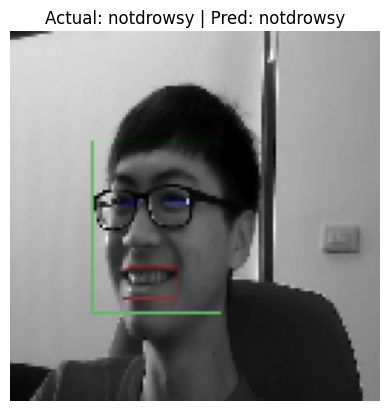

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


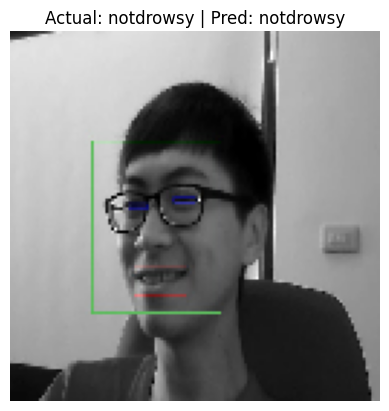

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


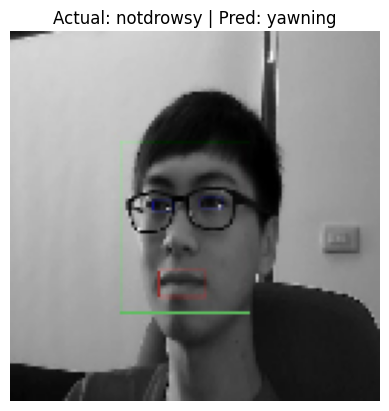

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


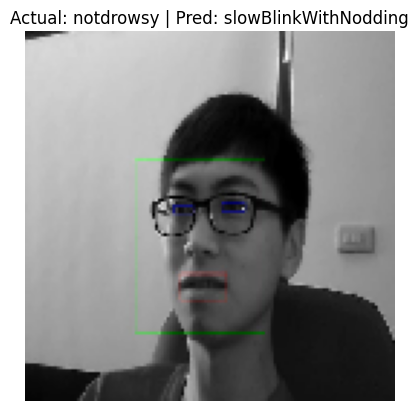

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


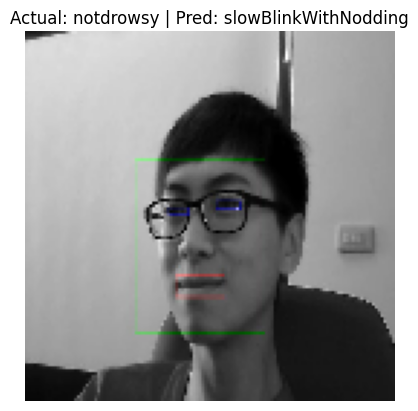

In [127]:
class_labels = list(test_generator.class_indices.keys())
best_model = mobilenet_model
for i in range(5):
    img, label = test_generator[i]
    pred = best_model.predict(img)

    plt.imshow(img[0])
    plt.title(f"Actual: {class_labels[np.argmax(label[0])]} | Pred: {class_labels[np.argmax(pred[0])]}")
    plt.axis('off')
    plt.show()